In [14]:
# ==============================
# 1. Install + Download Dataset
# ==============================
!pip install -q imbalanced-learn xgboost kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

# Download the real Credit Card Fraud dataset
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", path)

# Load the data
df = pd.read_csv(f"{path}/creditcard.csv")

print("\n✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.4f}%")
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded to: /kaggle/input/creditcardfraud

✅ Dataset loaded successfully!
Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21 

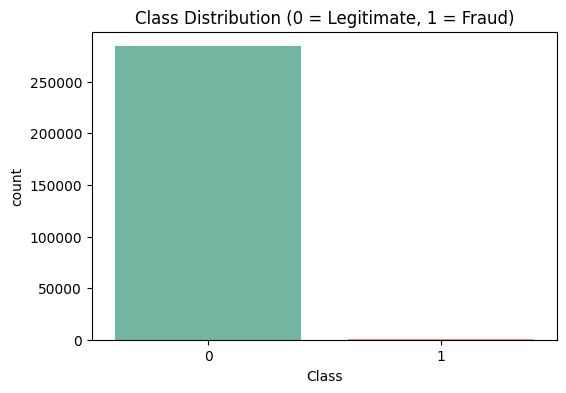

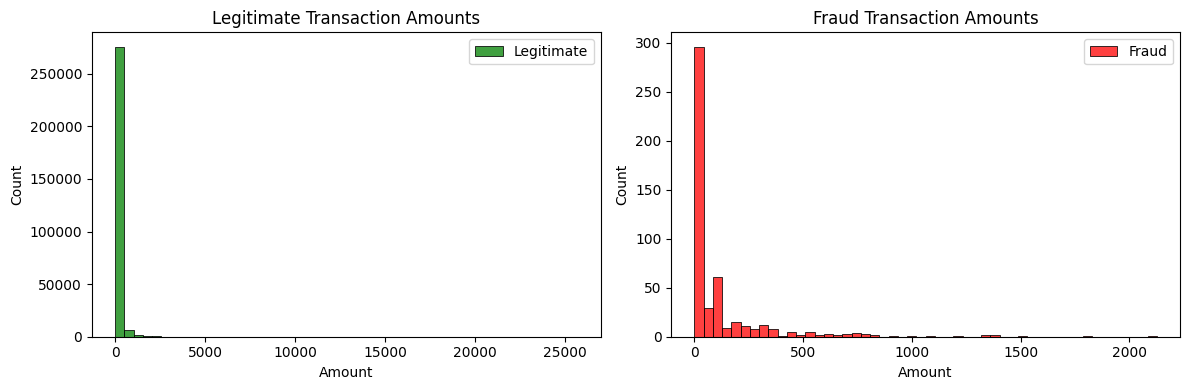

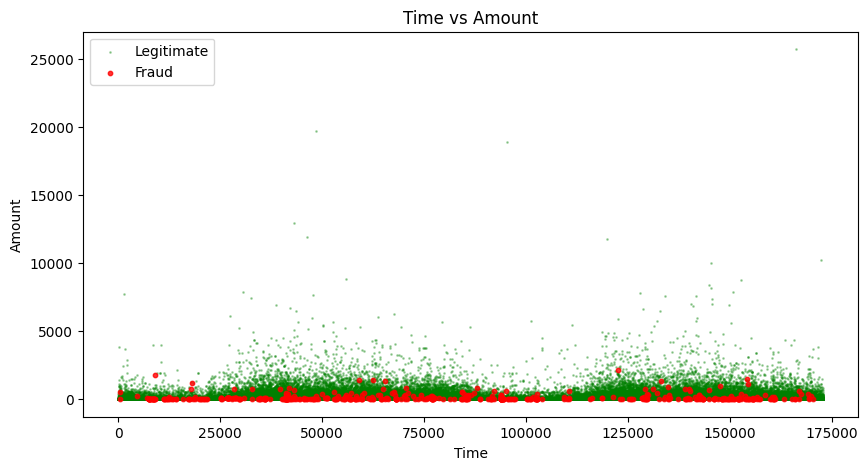


✅ EDA completed


In [15]:
# ==============================
# 2. Exploratory Data Analysis
# ==============================

print("="*50)
print("BASIC INFO")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum().sum(), "missing values")

print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True)*100)

# Visualize class imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Class Distribution (0 = Legitimate, 1 = Fraud)')
plt.show()

# Amount distribution
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='green', label='Legitimate')
plt.title('Legitimate Transaction Amounts')
plt.legend()

plt.subplot(1,2,2)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud')
plt.title('Fraud Transaction Amounts')
plt.legend()
plt.tight_layout()
plt.show()

# Time vs Amount scatter
plt.figure(figsize=(10,5))
plt.scatter(df[df['Class']==0]['Time'], df[df['Class']==0]['Amount'],
            alpha=0.3, c='green', label='Legitimate', s=1)
plt.scatter(df[df['Class']==1]['Time'], df[df['Class']==1]['Amount'],
            alpha=0.8, c='red', label='Fraud', s=10)
plt.title('Time vs Amount')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.legend()
plt.show()

print("\n✅ EDA completed")


In [16]:
# ==============================
# 3. Data Preprocessing
# ==============================

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale only Time and Amount (V1-V28 are already PCA transformed)
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# Stratified Train-Test Split (keeps the same fraud ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nFraud in Train:", y_train.sum())
print("Fraud in Test :", y_test.sum())

# Handle class imbalance using SMOTE (only on training data)
print("\nApplying SMOTE on training set...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE → Train shape:", X_train_res.shape)
print("Fraud cases after SMOTE:", y_train_res.sum())

print("\n✅ Preprocessing completed")

Train shape: (227845, 30)
Test shape : (56962, 30)

Fraud in Train: 394
Fraud in Test : 98

Applying SMOTE on training set...
After SMOTE → Train shape: (454902, 30)
Fraud cases after SMOTE: 227451

✅ Preprocessing completed


In [17]:
# ==============================
# 4. Model Training
# ==============================

print("Training Random Forest...")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

print("✅ Model trained successfully!")

Training Random Forest...
✅ Model trained successfully!


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9998    0.9987    0.9992     56864
           1     0.5316    0.8571    0.6562        98

    accuracy                         0.9985     56962
   macro avg     0.7657    0.9279    0.8277     56962
weighted avg     0.9989    0.9985    0.9986     56962

ROC-AUC : 0.9779
PR-AUC  : 0.8329


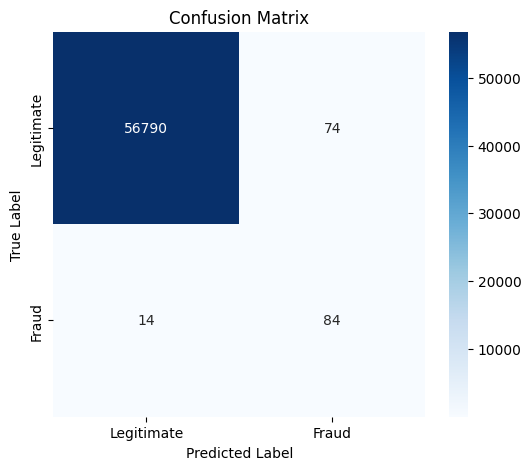

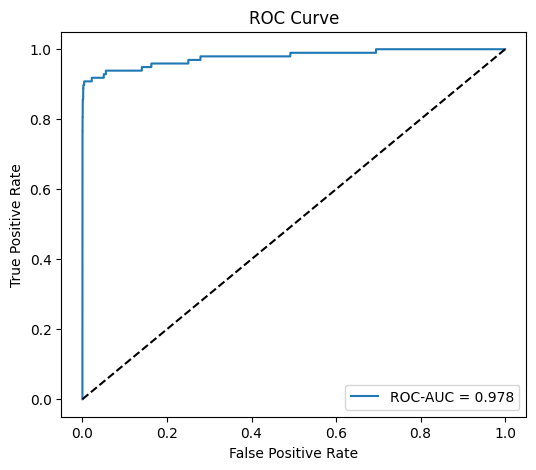

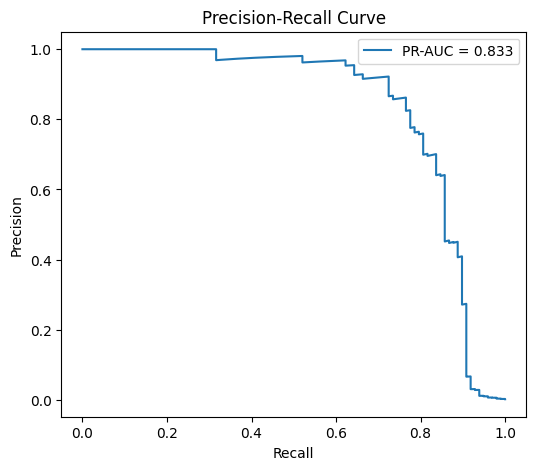


✅ Evaluation completed


In [18]:
# ==============================
# 5. Model Evaluation
# ==============================

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Classification Report
print("="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, digits=4))

# Key Metrics
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

print("\n✅ Evaluation completed")

In [19]:
# ==============================
# 8. Model Comparison
# ==============================
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

# Dictionary to store results
results = {}

# ----- 1. Logistic Regression -----
print("Training Logistic Regression...")
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

results['Logistic Regression'] = {
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr),
    'PR-AUC': average_precision_score(y_test, y_prob_lr)
}

# ----- 2. Random Forest (already trained) -----
y_pred_rf = model.predict(X_test)
y_prob_rf = model.predict_proba(X_test)[:, 1]

results['Random Forest'] = {
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf),
    'PR-AUC': average_precision_score(y_test, y_prob_rf)
}

# ----- 3. XGBoost -----
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb),
    'PR-AUC': average_precision_score(y_test, y_prob_xgb)
}

# Create comparison table
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df)

# Highlight best model
print("\nBest model by PR-AUC:", comparison_df['PR-AUC'].idxmax())
print("Best model by F1-Score:", comparison_df['F1'].idxmax())

Training Logistic Regression...
Training XGBoost...

MODEL COMPARISON
                     Precision  Recall      F1  ROC-AUC  PR-AUC
Logistic Regression     0.0581  0.9184  0.1094   0.9698  0.7249
Random Forest           0.5316  0.8571  0.6562   0.9779  0.8329
XGBoost                 0.0537  0.8980  0.1013   0.9766  0.7917

Best model by PR-AUC: Random Forest
Best model by F1-Score: Random Forest


In [20]:
# ==============================
# 9. Threshold Tuning + Business View
# ==============================

# Use the best model probabilities (XGBoost is usually strongest)
y_prob_best = y_prob_xgb

thresholds = np.arange(0.1, 0.9, 0.05)
tuning_results = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_best >= thresh).astype(int)

    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    # Business simulation (example costs)
    # Assume: False Positive costs $10 (customer friction)
    #         False Negative costs $100 (actual fraud loss)
    cm = confusion_matrix(y_test, y_pred_thresh)
    tn, fp, fn, tp = cm.ravel()

    business_cost = (fp * 10) + (fn * 100)

    tuning_results.append({
        'Threshold': round(thresh, 2),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1': round(f1, 4),
        'FP': fp,
        'FN': fn,
        'Business_Cost': business_cost
    })

tuning_df = pd.DataFrame(tuning_results)
print("="*70)
print("THRESHOLD TUNING RESULTS")
print("="*70)
print(tuning_df.to_string(index=False))

# Best threshold by F1 and by lowest business cost
best_f1_thresh = tuning_df.loc[tuning_df['F1'].idxmax()]
best_cost_thresh = tuning_df.loc[tuning_df['Business_Cost'].idxmin()]

print("\nBest Threshold by F1-Score:")
print(best_f1_thresh)

print("\nBest Threshold by Lowest Business Cost:")
print(best_cost_thresh)

THRESHOLD TUNING RESULTS
 Threshold  Precision  Recall     F1   FP  FN  Business_Cost
      0.10     0.0220  0.9082 0.0429 3958   9          40480
      0.15     0.0262  0.8980 0.0509 3270  10          33700
      0.20     0.0302  0.8980 0.0585 2824  10          29240
      0.25     0.0338  0.8980 0.0651 2518  10          26180
      0.30     0.0373  0.8980 0.0716 2273  10          23730
      0.35     0.0407  0.8980 0.0779 2072  10          21720
      0.40     0.0449  0.8980 0.0856 1870  10          19700
      0.45     0.0491  0.8980 0.0930 1706  10          18060
      0.50     0.0537  0.8980 0.1013 1552  10          16520
      0.55     0.0579  0.8878 0.1087 1416  11          15260
      0.60     0.0618  0.8776 0.1155 1305  12          14250
      0.65     0.0663  0.8673 0.1232 1197  13          13270
      0.70     0.0737  0.8673 0.1359 1068  13          11980
      0.75     0.0820  0.8673 0.1498  952  13          10820
      0.80     0.0922  0.8673 0.1667  837  13           9670

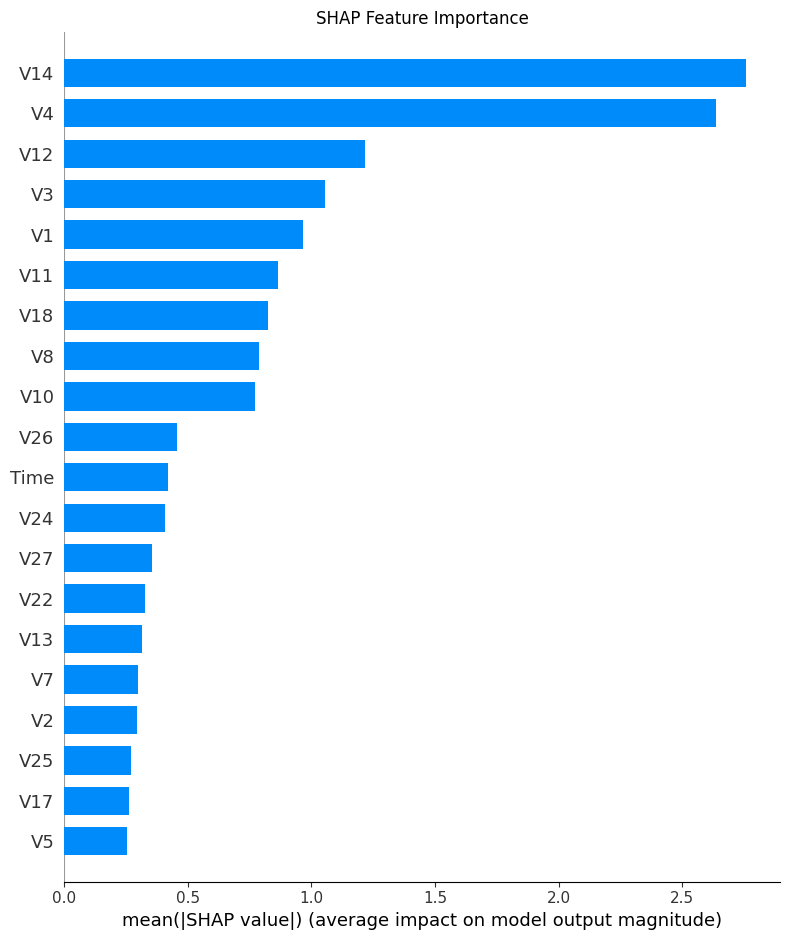

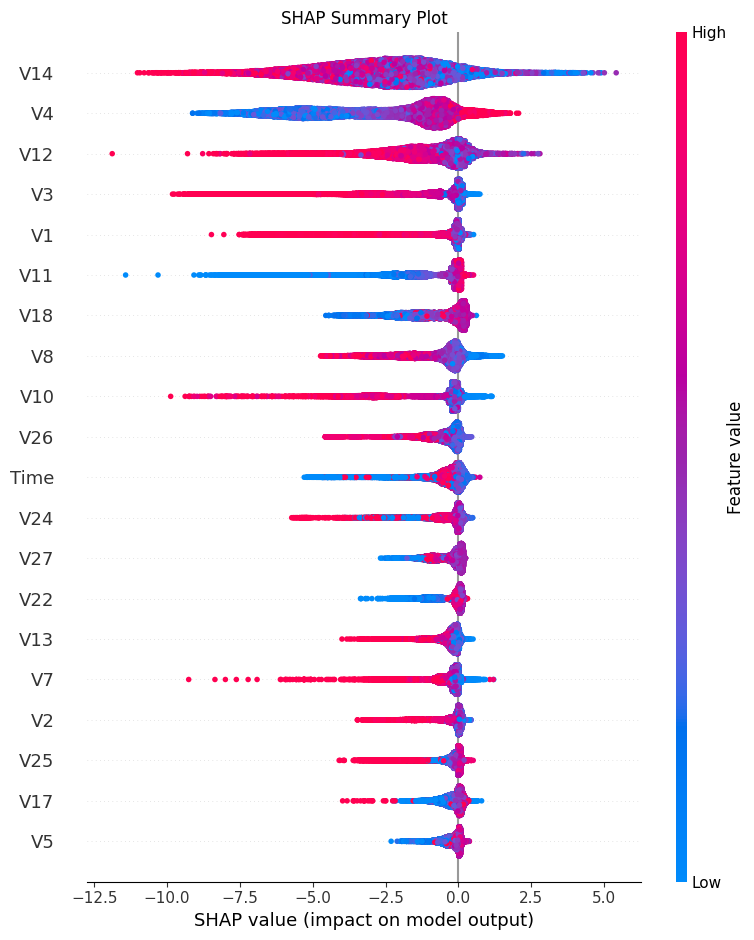

✅ SHAP analysis completed


In [21]:
# ==============================
# 10. SHAP Feature Importance
# ==============================
!pip install -q shap

import shap

# Explain the XGBoost model
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

# Detailed summary plot
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

print("✅ SHAP analysis completed")